# T12 Final Model Selection and Final Holdout Test Evaluation

T12 selects one final model from saved T11 Validation evidence, freezes every modeling decision, refits that one pipeline on Train+Validation, and evaluates the untouched chronological Test period once. Test is final evidence only: it cannot alter the model, representation, hyperparameters, preprocessing, or threshold.

In [1]:
from pathlib import Path
import hashlib
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'raw' / 'weatherAUS.csv').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from fdm_rainfall.data import load_weather_data, chronological_train_validation_test_split
from fdm_rainfall.final_model import (
    artifact_metadata_table, combine_train_validation_after_selection,
    compare_validation_and_test, fit_and_evaluate_final_model,
    frozen_configuration_table, load_final_bundle, prepare_final_data,
    save_final_bundle, save_final_figures,
    select_and_freeze_final_configuration,
)
from fdm_rainfall.preprocessing import predictor_columns

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'weatherAUS.csv'
TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'final_model'
ARTIFACT_PATH = PROJECT_ROOT / 'models' / 'final_rainfall_model.joblib'
EXPECTED_SHA256 = '573FD715CD69FCACC4DF32024D823B450AE3EDAAE7E8FF2EEB623ADBED424014'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 40)
pd.set_option('display.precision', 6)

prior_paths = [
    TABLE_DIR / '09_validation_baseline_comparison.csv',
    TABLE_DIR / '10_tuned_validation_metrics.csv',
    TABLE_DIR / '11_validation_metrics.csv',
    TABLE_DIR / '11_representation_winners.csv',
]
prior_hashes = {path: hashlib.sha256(path.read_bytes()).hexdigest() for path in prior_paths}

## Pre-Test evidence, selection policy, and freeze

Only the four T11-selected model/representation candidates and their saved Validation metrics are available to selection. The declared rule ranks full-precision Validation PR-AUC descending; the fixed model order is used only for an exact tie. Other metrics are interpretive and Test is unavailable to this step.

In [2]:
t11_validation = pd.read_csv(TABLE_DIR / '11_validation_metrics.csv')
t11_winners = pd.read_csv(TABLE_DIR / '11_representation_winners.csv')
expected_variants = t11_winners.set_index('Model')['Selected feature variant']
observed_variants = t11_validation.set_index('Model')['Selected feature variant']
assert observed_variants.equals(expected_variants)

selection = select_and_freeze_final_configuration(t11_validation)
frozen = selection.configuration
pretest_candidates = selection.candidates
frozen_table = frozen_configuration_table(frozen)
pretest_candidates.to_csv(TABLE_DIR / '12_pretest_candidate_selection.csv', index=False)
frozen_table.to_csv(TABLE_DIR / '12_final_frozen_configuration.csv', index=False)

assert frozen.model_family == pretest_candidates.iloc[0]['Model']
assert frozen.validation_metrics['PR-AUC'] == pretest_candidates.iloc[0]['PR-AUC']
assert frozen.test_consulted is False
assert frozen.threshold == 0.5
display(pretest_candidates)
display(frozen_table)
print(f'Frozen before Test access: {frozen.model_family} / {frozen.feature_variant}')

,Model,Selected feature variant,Processed feature count,Accuracy,Balanced Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,PR-AUC,TN,FP,FN,TP,Validation PR-AUC rank,Selected final model
0,Random Forest,V0_DEFAULT,89,0.859385,0.700083,0.781341,0.431066,0.555605,0.883234,0.704679,16465,525,2476,1876,1,Yes
1,Gradient Boosting,V1_ADD_YEAR,90,0.856855,0.704647,0.749519,0.447610,0.560495,0.875246,0.692330,16339,651,2404,1948,2,No
2,Logistic Regression,V2_LOG_RAINFALL_REPLACE,89,0.854278,0.704396,0.731199,0.451287,0.558113,0.870140,0.678523,16268,722,2388,1964,3,No
3,Decision Tree,V0_DEFAULT,89,0.800768,0.768042,0.508191,0.712776,0.593344,0.844848,0.635289,13988,3002,1250,3102,4,No


,Selected model family,Exact hyperparameters,Selected feature variant,Scaling route,Positive class,Negative class,Classification threshold,Selection rule,Exact tie-break required,Test consulted during selection,Configuration frozen before Test access,Estimator execution setting,Selection Validation Accuracy,Selection Validation Balanced Accuracy,Selection Validation Precision (Yes),Selection Validation Recall (Yes),Selection Validation F1 (Yes),Selection Validation ROC-AUC,Selection Validation PR-AUC
0,Random Forest,"{""class_weight"":null,""max_depth"":20,""max_featu...",V0_DEFAULT,unscaled,Yes,No,0.5,Highest full-precision T11 Validation PR-AUC; ...,No,No,Yes,n_jobs=1 (execution-only portability setting),0.859385,0.700083,0.781341,0.431066,0.555605,0.883234,0.704679


Frozen before Test access: Random Forest / V0_DEFAULT


## Final development population and preprocessing

The configuration above is now immutable. Validation has completed its selection role, so Train and Validation may be combined. Final feature engineering and preprocessing are fitted afresh on those 120,888 development rows; Test is transform-only.

In [3]:
raw = load_weather_data(DATA_PATH)
split = chronological_train_validation_test_split(raw)
assert [len(split.train), len(split.validation), len(split.test)] == [99_546, 21_342, 21_305]
development = combine_train_validation_after_selection(split.train, split.validation, frozen)
assert len(development) == 120_888
assert development['Date'].min().date().isoformat() == '2007-11-01'
assert development['Date'].max().date().isoformat() == '2016-04-08'
assert split.test['Date'].min().date().isoformat() == '2016-04-09'
assert split.test['Date'].max().date().isoformat() == '2017-06-25'

prepared = prepare_final_data(development, split.test, frozen)
assert prepared.preprocessor.fit_row_count_ == len(development)
assert prepared.preprocessor.fit_index_.equals(development.index)
assert set(prepared.X_development.index).isdisjoint(prepared.X_test.index)
assert list(prepared.X_development.columns) == list(prepared.X_test.columns)
print({
    'Development rows': len(prepared.X_development),
    'Test rows': len(prepared.X_test),
    'Processed features': prepared.X_development.shape[1],
    'Scaling route': 'scaled' if frozen.scale_numeric else 'unscaled',
})

{'Development rows': 120888, 'Test rows': 21305, 'Processed features': 89, 'Scaling route': 'unscaled'}


## One-time selected-model Test evaluation

Only the frozen selected estimator is constructed. It is fitted once on processed Train+Validation, then its RainTomorrow=Yes probabilities are evaluated on Test at the unchanged 0.5 threshold. No alternative candidate receives Test data.

In [4]:
final_evaluation = fit_and_evaluate_final_model(prepared, frozen)
final_metrics = final_evaluation.comparison
confusion_counts = final_metrics.loc[:, [
    'Model', 'Selected feature variant', 'TN', 'FP', 'FN', 'TP'
]]
assert len(final_metrics) == 1
assert final_metrics.iloc[0]['Model'] == frozen.model_family
assert final_metrics.iloc[0]['Threshold'] == 0.5
final_metrics.to_csv(TABLE_DIR / '12_final_test_metrics.csv', index=False)
confusion_counts.to_csv(TABLE_DIR / '12_final_test_confusion_counts.csv', index=False)
display(final_metrics)
display(confusion_counts)

,Model,Selected feature variant,Processed feature count,Development rows,Test rows,Threshold,Accuracy,Balanced Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Random Forest,V0_DEFAULT,89,120888,21305,0.5,0.844215,0.724577,0.766068,0.496447,0.602467,0.875865,0.729349,15471,768,2551,2515


,Model,Selected feature variant,TN,FP,FN,TP
0,Random Forest,V0_DEFAULT,15471,768,2551,2515


## Validation-to-Test generalization

Metric changes describe performance in the later chronological period; they do not reopen selection. Class imbalance and the balance between false positives and false negatives remain central to interpretation. No causal or statistical-significance claim is made.

In [5]:
validation_vs_test = compare_validation_and_test(frozen, final_metrics)
validation_vs_test.to_csv(TABLE_DIR / '12_validation_vs_test_metrics.csv', index=False)
display(validation_vs_test)
print('Test results are final evidence; configuration remains frozen and unchanged.')

,Metric,T11 Validation,Final Test,Test minus Validation,Direction
0,Accuracy,0.859385,0.844215,-0.015170,Declined
1,Balanced Accuracy,0.700083,0.724577,0.024494,Improved
2,Precision (Yes),0.781341,0.766068,-0.015273,Declined
3,Recall (Yes),0.431066,0.496447,0.065381,Improved
4,F1 (Yes),0.555605,0.602467,0.046862,Improved
5,ROC-AUC,0.883234,0.875865,-0.007369,Declined
6,PR-AUC,0.704679,0.729349,0.024670,Improved


Test results are final evidence; configuration remains frozen and unchanged.


## Final selected-model figures

All Test figures contain only the single frozen final model.

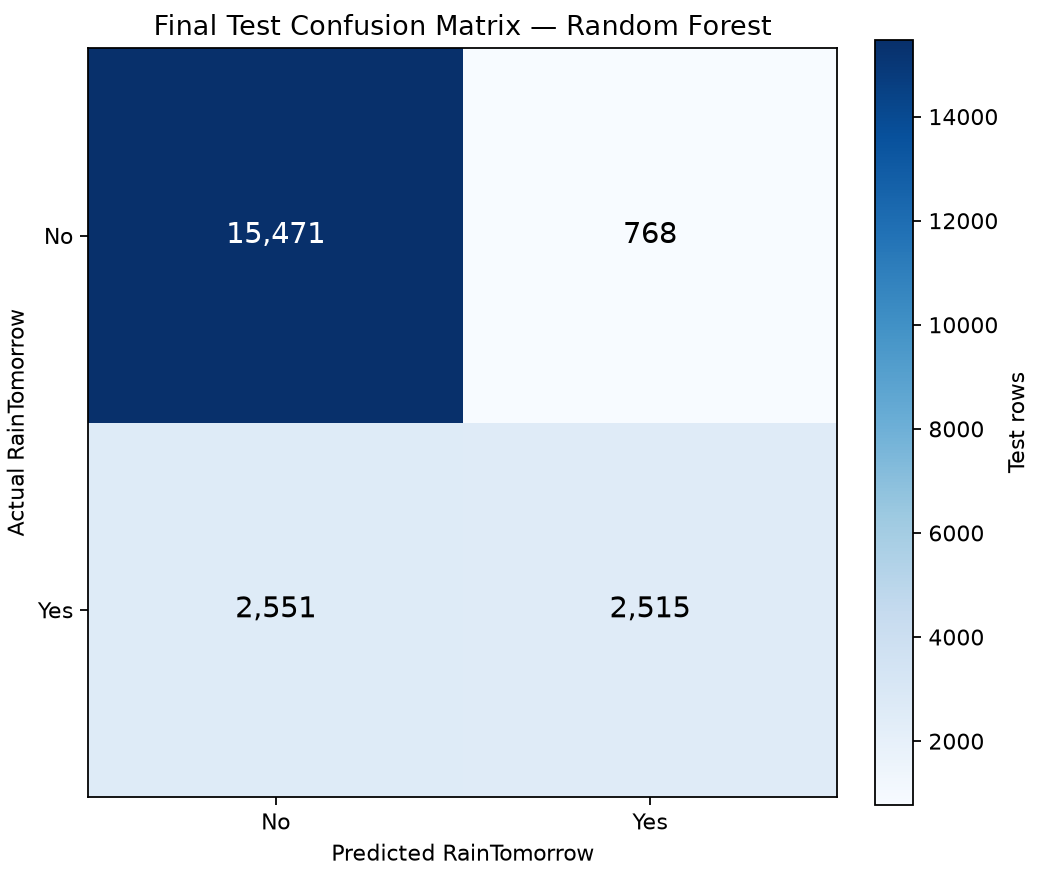

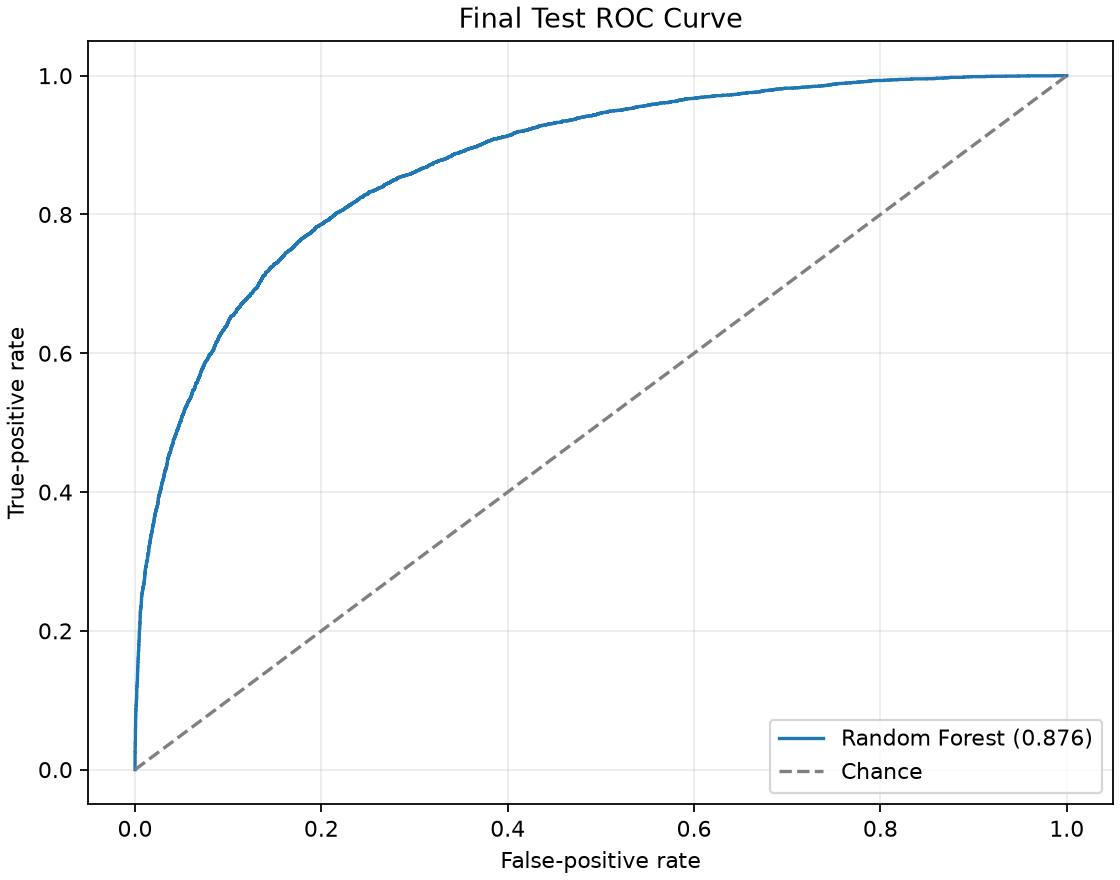

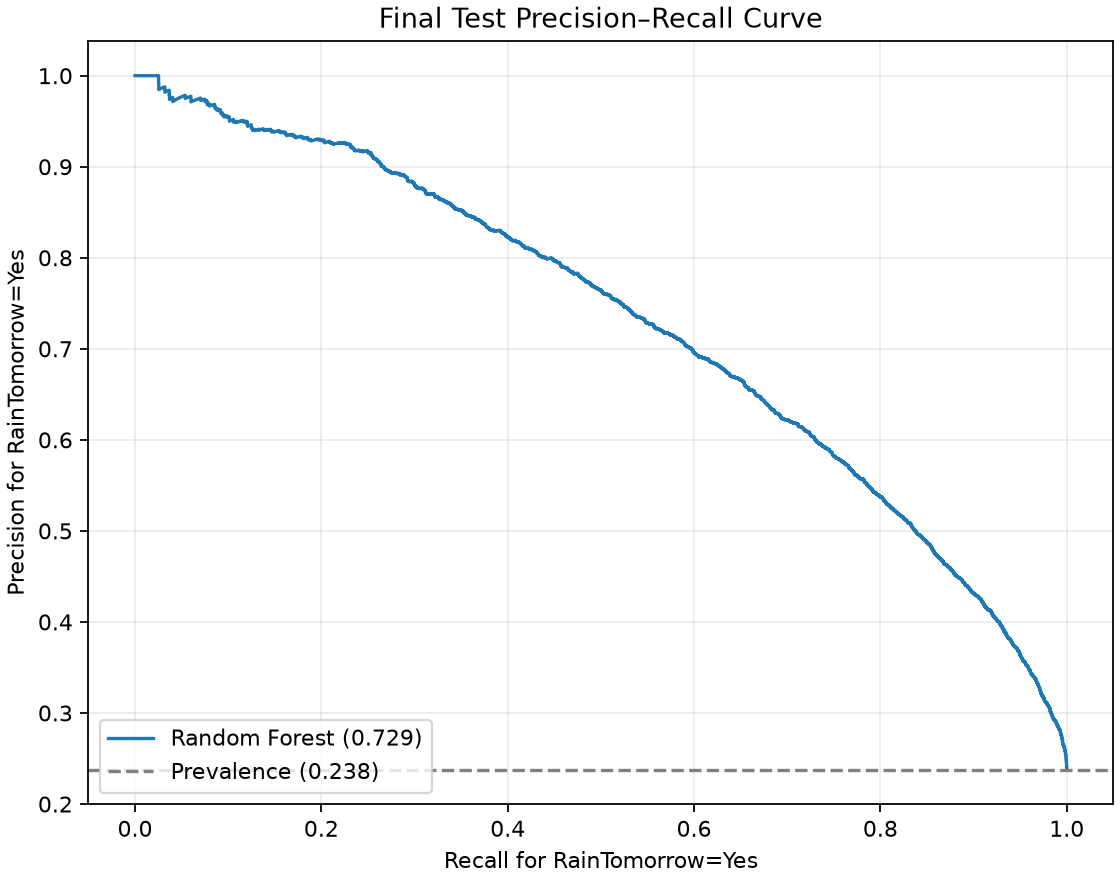

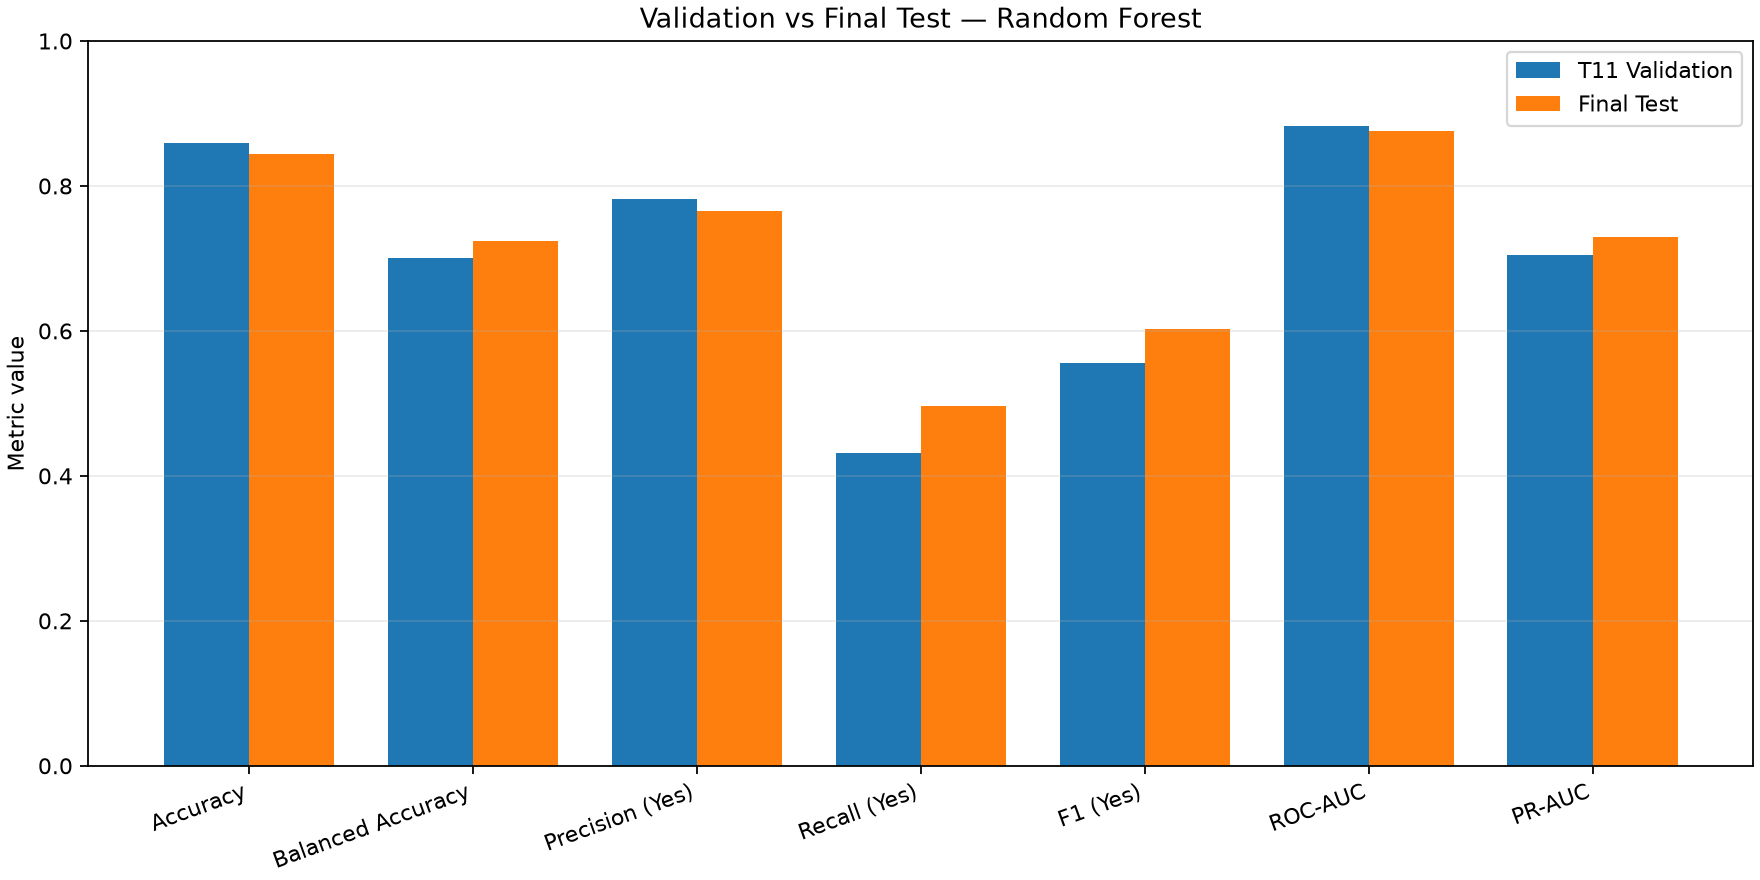

In [6]:
figure_paths = save_final_figures(
    final_evaluation, prepared.y_test, validation_vs_test, FIGURE_DIR
)
assert len(figure_paths) == 4
for figure_path in figure_paths:
    display(Image(filename=figure_path))

## Persisted model and serialization integrity

The deployable bundle contains the selected estimator, Train+Validation-fitted preprocessor, ordered processed schema, expected raw schema, threshold, positive class, and provenance metadata. It excludes Test labels and raw datasets. A small inference sample verifies label and probability equivalence after loading.

In [7]:
saved_artifact = save_final_bundle(final_evaluation.bundle, ARTIFACT_PATH)
loaded_bundle = load_final_bundle(saved_artifact)
raw_sample = split.test.loc[:, ['Date', *predictor_columns()]].head(128).copy()
sample_before = raw_sample.copy(deep=True)
original_labels = final_evaluation.bundle.predict(raw_sample)
loaded_labels = loaded_bundle.predict(raw_sample)
original_probabilities = final_evaluation.bundle.predict_positive_probability(raw_sample)
loaded_probabilities = loaded_bundle.predict_positive_probability(raw_sample)
labels_match = np.array_equal(original_labels, loaded_labels)
probabilities_match = np.allclose(original_probabilities, loaded_probabilities)
assert labels_match and probabilities_match
pd.testing.assert_frame_equal(raw_sample, sample_before)
artifact_metadata = artifact_metadata_table(
    loaded_bundle, saved_artifact, labels_match, probabilities_match
)
artifact_metadata.to_csv(TABLE_DIR / '12_final_artifact_metadata.csv', index=False)
display(artifact_metadata)

,Artifact path,Artifact bytes,Bundle type,Model version,Model family,Feature variant,Processed feature count,Development rows,Development date range,Test evaluation date range,Positive class,Threshold,Contains Test labels,Round-trip labels match,Round-trip probabilities match
0,D:/11.Running Projects/FDM Mini Project/FDM_Mi...,46192112,FinalRainfallModelBundle,T12-final-v1,Random Forest,V0_DEFAULT,89,120888,2007-11-01 to 2016-04-08,2016-04-09 to 2017-06-25,Yes,0.5,No,Yes,Yes


## T12 and Progress Evaluation 2 boundary

T12 ends the modeling and optimization implementation stage. The Test result does not trigger tuning, feature changes, threshold changes, or another model comparison. Backend and frontend work remain outside this task.

In [8]:
observed_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest().upper()
assert observed_sha256 == EXPECTED_SHA256
assert all(hashlib.sha256(path.read_bytes()).hexdigest() == prior_hashes[path] for path in prior_paths)
assert final_evaluation.bundle.configuration == frozen
assert final_evaluation.bundle.metadata['post_test_model_changes'] is False
print(f'Raw SHA-256: {observed_sha256}')
print('Serialization labels match:', labels_match)
print('Serialization probabilities match:', probabilities_match)
print('Exactly one selected model evaluated on Test:', frozen.model_family)
print('No post-Test model or threshold changes were made.')
print('T12 complete; PE2 modeling/optimization implementation complete.')

Raw SHA-256: 573FD715CD69FCACC4DF32024D823B450AE3EDAAE7E8FF2EEB623ADBED424014
Serialization labels match: True
Serialization probabilities match: True
Exactly one selected model evaluated on Test: Random Forest
No post-Test model or threshold changes were made.
T12 complete; PE2 modeling/optimization implementation complete.
